11490434/11490434 [==============================] - 2s 0us/step

Training CNN Model...
Epoch 1/5
1688/1688 [==============================] - 33s 18ms/step - loss: 0.1572 - accuracy: 0.9542 - val_loss: 0.0697 - val_accuracy: 0.9808
Epoch 2/5
1688/1688 [==============================] - 29s 17ms/step - loss: 0.0546 - accuracy: 0.9833 - val_loss: 0.0475 - val_accuracy: 0.9872
Epoch 3/5
1688/1688 [==============================] - 28s 17ms/step - loss: 0.0342 - accuracy: 0.9891 - val_loss: 0.0505 - val_accuracy: 0.9875
Epoch 4/5
1688/1688 [==============================] - 43s 25ms/step - loss: 0.0224 - accuracy: 0.9929 - val_loss: 0.0506 - val_accuracy: 0.9872
Epoch 5/5
1688/1688 [==============================] - 40s 24ms/step - loss: 0.0157 - accuracy: 0.9950 - val_loss: 0.0481 - val_accuracy: 0.9872

Training Random Forest Model...

Model Performance:
CNN Test Accuracy: 0.9873
RF Test Accuracy: 0.9692

CNN Predictions on Sample Test Images:
1/1 [==============================] - 0s 3

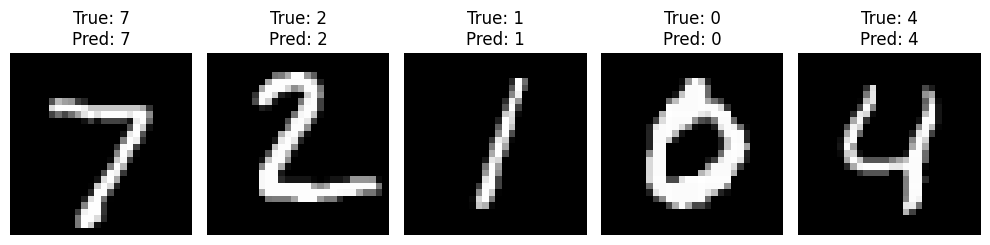


Random Forest Predictions on Sample Test Images:


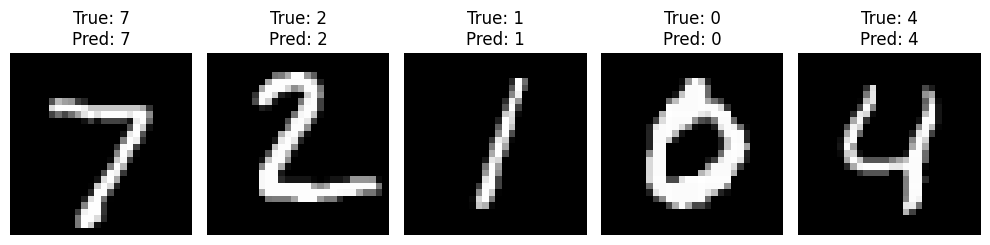

In [1]:
# Handwritten Digit Recognition System
# Using MNIST dataset with CNN and Random Forest

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load and Prepare Data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension for CNN (28, 28) -> (28, 28, 1)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

# Flatten images for Random Forest
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

# 2. CNN Model
print("\nTraining CNN Model...")
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

cnn_model.fit(X_train_cnn, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 3. Random Forest Model
print("\nTraining Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_flat, y_train)

# 4. Evaluation
# CNN Evaluation
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

# RF Evaluation
rf_pred = rf_model.predict(X_test_flat)
rf_test_acc = accuracy_score(y_test, rf_pred)

print("\nModel Performance:")
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"RF Test Accuracy: {rf_test_acc:.4f}")

# 5. Prediction Example
def predict_and_show(model, images, labels, model_type='cnn'):
    plt.figure(figsize=(10,5))
    for i in range(5):
        plt.subplot(1,5,i+1)
        if model_type == 'cnn':
            img = images[i][..., np.newaxis]
            pred = np.argmax(model.predict(np.array([img])))
        else:
            img = images[i].reshape(1, -1)
            pred = model.predict(img)[0]
        plt.imshow(images[i], cmap='gray')
        plt.title(f"True: {labels[i]}\nPred: {pred}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nCNN Predictions on Sample Test Images:")
predict_and_show(cnn_model, X_test, y_test, 'cnn')

print("\nRandom Forest Predictions on Sample Test Images:")
predict_and_show(rf_model, X_test, y_test, 'rf')